In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Load the native 2-way split
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Carve out the Validation set from the Training set
# We will take 10,000 images for validation, leaving 50,000 for training
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=10000,
    random_state=42
)

# 3. Normalize the pixels (Crucial step!)
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 4. Reshape for a Convolutional Neural Network (Adding the color channel)
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 5. Build the tf.data Pipelines
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

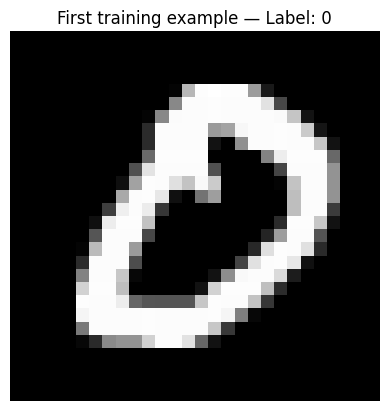

In [6]:
import matplotlib.pyplot as plt
# Visualize the first digit in x_train
plt.imshow(x_train[4223, :, :, 0], cmap='gray')
plt.title(f"First training example — Label: {y_train[4223]}")
plt.axis('off')
plt.show()

In [18]:
model = tf.keras.Sequential([

    tf.keras.layers.RandomRotation(factor=0.05, input_shape=(28, 28, 1)), # +/- 18 degrees
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Shift up/down/left/right
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1), # Zoom in/out slightly

     tf.keras.layers.Flatten(),

    # --- HIDDEN LAYER 1 ---
    tf.keras.layers.Dense(124, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.2), # Lowered to 20%

    # --- HIDDEN LAYER 2 ---
    tf.keras.layers.Dense(64, kernel_initializer="he_normal", use_bias=False), # Slightly smaller
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.2),

    # --- OUTPUT LAYER ---
    tf.keras.layers.Dense(10, activation='softmax')
])

In [19]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
                metrics=["accuracy"])

In [20]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # What to watch (default is 'val_loss')
    patience=10,         # How many epochs to wait (passed as a keyword argument)
    restore_best_weights=True
)

history=model.fit(x_train,y_train,epochs=1000,
                  validation_data=(x_val,y_val),
                  callbacks=[early_stopping])

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6063 - loss: 1.2012 - val_accuracy: 0.9112 - val_loss: 0.3167
Epoch 2/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7772 - loss: 0.6943 - val_accuracy: 0.9383 - val_loss: 0.2296
Epoch 3/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8053 - loss: 0.6069 - val_accuracy: 0.9352 - val_loss: 0.2247
Epoch 4/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8234 - loss: 0.5576 - val_accuracy: 0.9493 - val_loss: 0.1776
Epoch 5/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8335 - loss: 0.5390 - val_accuracy: 0.9581 - val_loss: 0.1556
Epoch 6/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8366 - loss: 0.5159 - val_accuracy: 0.9619 - val_loss: 0.1468
Epoch 7/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8407 - loss: 0.5033 - val_accuracy: 0.9491 - val_loss: 0.1815
Epoch 8/1000
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 

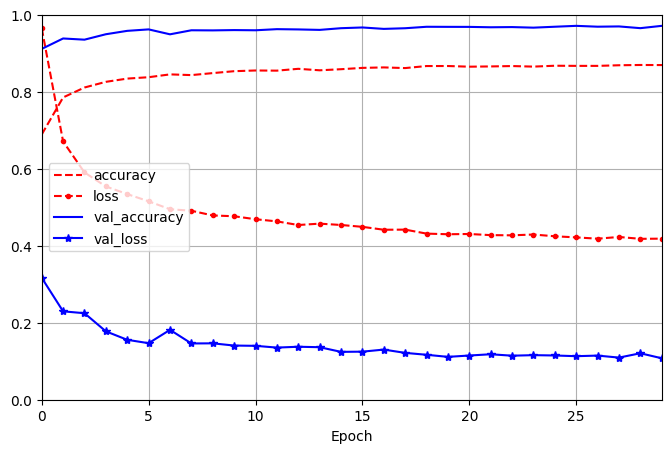

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8,5),xlim=(0,29),ylim=(0,1),grid=True,
xlabel='Epoch',
style=["r--", "r--.", "b-", "b-*"])

plt.show()

In [37]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def prepare_my_image(image_path):
    # 1. Load, grayscale, and resize
    img = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(28, 28)
    )
    img_array = tf.keras.utils.img_to_array(img)

    # 2. Invert the colors (White paper -> Black, Dark ink -> White)
    img_array = 255.0 - img_array

    # 3. Normalize to decimals (0.0 to 1.0)
    img_array = img_array / 255.0

    # --- 4. THE NEW FIX: THRESHOLDING ---
    # Any annoying gray background noise (below 0.5) gets crushed to pure black (0.0)
    img_array = np.where(img_array < 0.5, 0.0, img_array)

    # Any light gray ink gets boosted to pure bright white (1.0)
    img_array = np.where(img_array > 0.5, 1.0, img_array)

    # --- 5. VISUAL CHECK ---
    # Let's plot it right inside the function so you can immediately see if it worked
    plt.imshow(img_array[:, :, 0], cmap='gray')
    plt.title("Upgraded Thresholded Image")
    plt.colorbar()
    plt.show()

    # 6. Add the Batch dimension for the model
    final_input = tf.expand_dims(img_array, axis=0)

    return final_input

# Run it again!
# my_ready_image = prepare_my_image_v2("my_handwritten_digit.jpg")


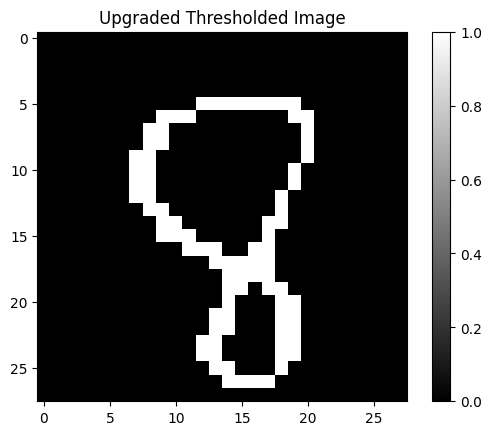

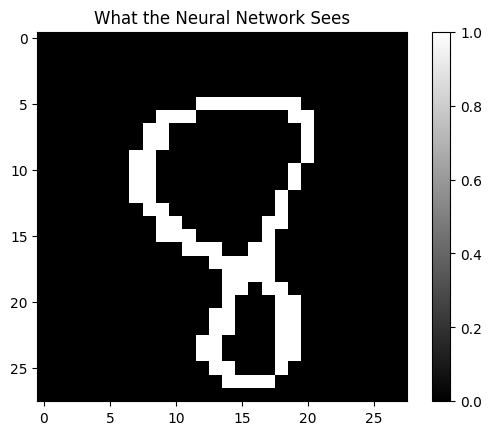

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Raw Probabilities: [[4.22016965e-05 6.28460315e-04 1.26434015e-02 8.65876023e-03
  2.97302790e-02 3.47848088e-02 9.47165128e-04 1.25255180e-03
  8.93948674e-01 1.73637327e-02]]
The model is 89.39% sure this is a 8!


In [42]:
import numpy as np

my_ready_image = prepare_my_image("new8.png")
# 1. Pass your prepared image into the model
# (Assuming 'my_ready_image' is the output from the function we just wrote)

import matplotlib.pyplot as plt

# (Assuming my_ready_image is the output of your preparation function)
# Let's pull the 28x28 grid back out of the batch
image_to_view = my_ready_image[0, :, :, 0]

# Display it exactly how the model sees it
plt.imshow(image_to_view, cmap='gray')
plt.title("What the Neural Network Sees")
plt.colorbar() # This shows you if the background is truly 0.0 (black)
plt.show()

raw_predictions = model.predict(my_ready_image)

# Optional: Print the raw math just to see what the neural network is "thinking"
print("Raw Probabilities:", raw_predictions)

# 2. Find the POSITION (index) of the highest probability
# Since index 0 represents the digit 0, index 1 is 1, etc.,
# the index perfectly matches our predicted digit!
predicted_digit = np.argmax(raw_predictions)

# 3. Grab the actual confidence score for that winning digit
confidence_decimal = np.max(raw_predictions)
confidence_percentage = confidence_decimal * 100

# 4. Print the final, human-readable result
print(f"The model is {confidence_percentage:.2f}% sure this is a {predicted_digit}!")

In [43]:
# Save the entire model to a single file
model.save('my_mnist_model.keras')

print("Model successfully saved!")

Model successfully saved!
